23070521135 - Sharvayu Zade

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.1775 - val_loss: 0.0744
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0711 - val_loss: 0.0679
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0675 - val_loss: 0.0661


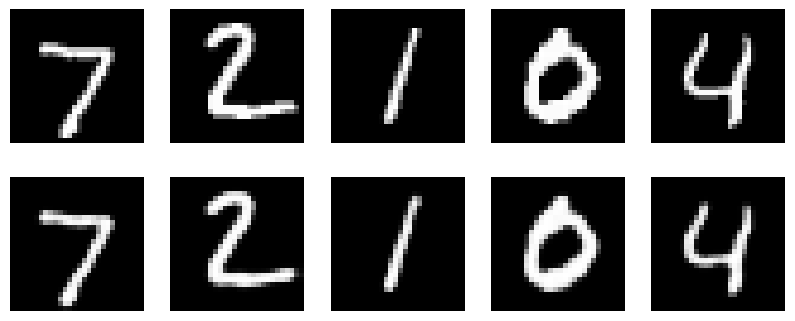

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(8, 3, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(8, 3, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(16, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(1, 3, activation="sigmoid", padding="same")
])

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.fit(x_train, x_train, epochs=3, batch_size=128, validation_data=(x_test, x_test))

reconstructed = autoencoder.predict(x_test[:5], verbose=0)
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.show()